In [ ]:
from google.colab import files
uploaded = files.upload()

Saving background.csv to background.csv
Saving circle.csv to circle.csv
Saving rest.csv to rest.csv
Saving shake.csv to shake.csv
Saving updown.csv to updown.csv


In [ ]:
import pandas as pd
import numpy as np

dfs = []
for fname in uploaded.keys():
    df = pd.read_csv(fname)
    df = df[~df['ax'].astype(str).str.startswith('#')]
    df = df[df['ax'] != 'ax']
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data = data.astype({'ax': float, 'ay': float, 'az': float,
                    'gx': float, 'gy': float, 'gz': float})

print("Total rows:", len(data))
print(data['label'].value_counts())

Total rows: 10000
label
background    2000
circle        2000
rest          2000
shake         2000
updown        2000
Name: count, dtype: int64


In [ ]:
def extract_features(window):
    features = []
    cols = ['ax','ay','az','gx','gy','gz']

    for col in cols:
        s = window[col].values
        features.append(float(np.mean(s)))
        features.append(float(np.std(s)))
        features.append(float(np.sqrt(np.mean(s**2))))
        features.append(float(np.min(s)))
        features.append(float(np.max(s)))

    for col in cols:
        s = window[col].values
        fft_vals = np.fft.fft(s)
        for k in range(1, 6):
            re = fft_vals[k].real
            im = fft_vals[k].imag
            features.append(re * re + im * im)

    return features

WINDOW_SIZE = 50
STEP = 25
cols = ['ax','ay','az','gx','gy','gz']
X_list, y_list = [], []

for i in range(0, len(data) - WINDOW_SIZE, STEP):
    window = data[cols].iloc[i:i+WINDOW_SIZE]
    labels_in_window = data['label'].iloc[i:i+WINDOW_SIZE].values
    unique, counts = np.unique(labels_in_window, return_counts=True)
    majority = unique[np.argmax(counts)]
    X_list.append(extract_features(window))
    y_list.append(majority)

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list)
print("Feature matrix shape:", X.shape)
print("Classes found:", np.unique(y))

Feature matrix shape: (398, 60)
Classes found: ['background' 'circle' 'rest' 'shake' 'updown']


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Class order:", list(le.classes_))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Class order: [np.str_('background'), np.str_('circle'), np.str_('rest'), np.str_('shake'), np.str_('updown')]
Train size: 318
Test size: 80


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

early_stop = callbacks.EarlyStopping(
    patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,149 (24.02 KB)

 Trainable params: 6,149 (24.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3780 - loss: 1.5701 - val_accuracy: 0.5781 - val_loss: 1.2254
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6850 - loss: 1.0775 - val_accuracy: 0.7500 - val_loss: 0.9161
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7795 - loss: 0.8320 - val_accuracy: 0.8281 - val_loss: 0.6906
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8386 - loss: 0.6558 - val_accuracy: 0.9375 - val_loss: 0.5287
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8937 - loss: 0.5131 - val_accuracy: 0.9531 - val_loss: 0.3902
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9291 - loss: 0.4096 - val_accuracy: 0.9844 - val_loss: 0.2690
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9528 - loss: 0.3206 - val_accuracy: 0.9844 - val_loss: 0.1893
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9409 - loss: 0.2704 - val_accuracy: 0.9844 - 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


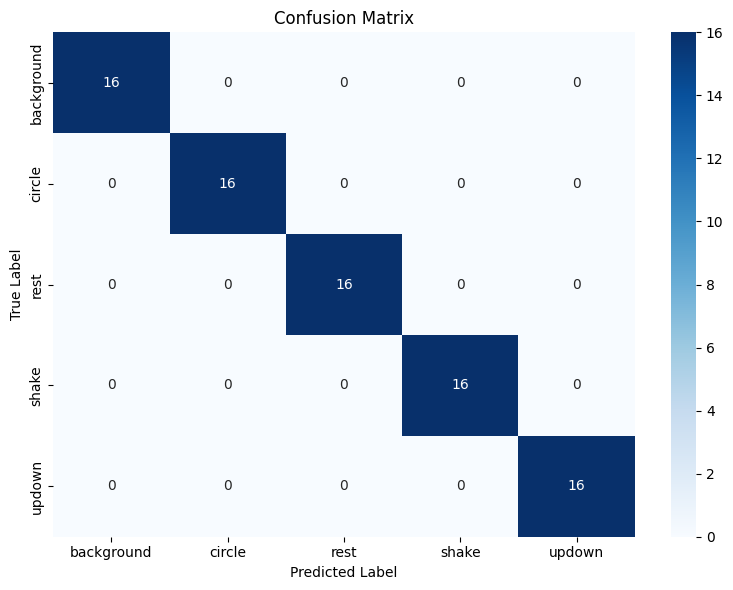

              precision    recall  f1-score   support

  background       1.00      1.00      1.00        16
      circle       1.00      1.00      1.00        16
        rest       1.00      1.00      1.00        16
       shake       1.00      1.00      1.00        16
      updown       1.00      1.00      1.00        16

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=le.classes_))

In [ ]:
print("// =============================================")
print("// PASTE THIS INTO YOUR ARDUINO SKETCH")
print("// =============================================\n")

print(f"const int NUM_FEATURES = {X.shape[1]};")
print(f"const int NUM_CLASSES = {len(le.classes_)};")
names = ", ".join([f'"{c}"' for c in le.classes_])
print(f'const char* CLASS_NAMES[] = {{{names}}};\n')

print(f"const float SCALER_MEAN[{X.shape[1]}] = {{")
vals = ", ".join([f"{v:.6f}f" for v in scaler.mean_])
print(f"  {vals}")
print("};\n")

print(f"const float SCALER_SCALE[{X.shape[1]}] = {{")
vals = ", ".join([f"{v:.6f}f" for v in scaler.scale_])
print(f"  {vals}")
print("};\n")

print("// Class order:", list(le.classes_))

// =============================================
// PASTE THIS INTO YOUR ARDUINO SKETCH
// =============================================

const int NUM_FEATURES = 60;
const int NUM_CLASSES = 5;
const char* CLASS_NAMES[] = {"background", "circle", "rest", "shake", "updown"};

const float SCALER_MEAN[60] = {
  -0.009563f, 0.159779f, 0.230537f, -0.339502f, 0.287114f, -0.113168f, 0.262355f, 0.373151f, -0.616667f, 0.399613f, 0.885751f, 0.242848f, 0.991056f, 0.430665f, 1.375752f, 0.209583f, 42.138461f, 43.047510f, -100.132157f, 84.731054f, 0.729481f, 39.285409f, 39.663778f, -76.074645f, 79.888729f, 1.555488f, 48.934521f, 49.380999f, -87.182121f, 94.603568f, 6.373422f, 10.866618f, 6.418313f, 4.136916f, 5.227263f, 11.072044f, 15.389019f, 12.773253f, 30.066066f, 41.960031f, 27.028416f, 51.553695f, 25.341868f, 13.924404f, 12.647660f, 1804114.455018f, 2150772.201762f, 1209919.083383f, 1159776.145863f, 649020.228859f, 362377.629011f, 1456988.598149f, 799754.964728f, 455167.308610f, 240735.072637f,

In [ ]:
from google.colab import files

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

print(f"Model size: {len(tflite_model)} bytes")

with open('gesture_model.h', 'w') as f:
    f.write('#pragma once\n\n')
    f.write(f'const unsigned int model_tflite_len = {len(tflite_model)};\n')
    f.write('__attribute__((aligned(8))) const unsigned char model_tflite[] = {\n  ')
    hex_data = ['0x{:02x}'.format(b) for b in tflite_model]
    f.write(',\n  '.join(
        ', '.join(hex_data[i:i+12]) for i in range(0, len(hex_data), 12)
    ))
    f.write('\n};\n')

files.download('gesture_model.h')
print("gesture_model.h downloaded!")

Saved artifact at '/tmp/tmpflg_ekan'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  140526595536272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140528125510480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140528125512592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140528125511248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140528125511632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140528125513168: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model size: 26716 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

gesture_model.h downloaded!


In [ ]:
# Run inference on a sample to confirm no NaN outputs
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
inp = interpreter.get_input_details()
out = interpreter.get_output_details()

test_input = np.zeros((1, X.shape[1]), dtype=np.float32)
interpreter.set_tensor(inp[0]['index'], test_input)
interpreter.invoke()
result = interpreter.get_tensor(out[0]['index'])

print("Test output:", result)
print("Any NaN:", np.any(np.isnan(result)))
print("Sum of probabilities:", np.sum(result))
print("\nIf Any NaN is False and Sum is close to 1.0 — model is good to go!")

Test output: [[0.25065425 0.2763663  0.11781702 0.19253752 0.16262496]]
Any NaN: False
Sum of probabilities: 1.0000001

If Any NaN is False and Sum is close to 1.0 — model is good to go!


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
